In [ ]:
# Import required libraries
    
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
# Load the weather dataset
df = pd.read_csv("Weather_Data")
df.head()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog


In [42]:
# Check the number of rows and columns
df.shape

(8784, 8)

In [43]:
# Display column names
df.columns

Index(['Date/Time', 'Temp_C', 'Dew Point Temp_C', 'Rel Hum_%',
       'Wind Speed_km/h', 'Visibility_km', 'Press_kPa', 'Weather'],
      dtype='object')

In [44]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date/Time         8784 non-null   object 
 1   Temp_C            8784 non-null   float64
 2   Dew Point Temp_C  8784 non-null   float64
 3   Rel Hum_%         8784 non-null   int64  
 4   Wind Speed_km/h   8784 non-null   int64  
 5   Visibility_km     8784 non-null   float64
 6   Press_kPa         8784 non-null   float64
 7   Weather           8784 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 549.1+ KB


In [45]:
# Generate statistical summary for numerical columns
df.describe()

,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa
count,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,8.798144,2.555294,67.431694,14.945469,27.664447,101.051623
std,11.687883,10.883072,16.918881,8.688696,12.622688,0.844005
min,-23.300000,-28.500000,18.000000,0.000000,0.200000,97.520000
25%,0.100000,-5.900000,56.000000,9.000000,24.100000,100.560000
50%,9.300000,3.300000,68.000000,13.000000,25.000000,101.070000
75%,18.800000,11.800000,81.000000,20.000000,25.000000,101.590000
max,33.000000,24.400000,100.000000,83.000000,48.300000,103.650000


In [ ]:
# Generate summary for categorical columns
df.describe(include="object")                  

,Date/Time,Weather
count,8784,8784
unique,8784,50
top,1/1/2012 0:00,Mainly Clear
freq,1,2106


In [49]:
# Check missing values in each column
df.isnull().sum()

Date/Time           0
Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Visibility_km       0
Press_kPa           0
Weather             0
dtype: int64

In [52]:
# Convert Date/Time from object to datetime format
df["Date/Time"] = pd.to_datetime(df["Date/Time"])
df["Date/Time"].dtype

dtype('<M8[ns]')

In [53]:
# Extract useful time-based features from Date/Time
df["Year"] = df["Date/Time"].dt.year
df["Month"] = df["Date/Time"].dt.month
df["Day"] = df["Date/Time"].dt.day
df["Hour"] = df["Date/Time"].dt.hour
df["Day_Name"] = df["Date/Time"].dt.day_name()

df.head()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather,Year,Month,Day,Hour,Day_Name
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog,2012,1,1,0,Sunday
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog,2012,1,1,1,Sunday
2,2012-01-01 02:00:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog",2012,1,1,2,Sunday
3,2012-01-01 03:00:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog",2012,1,1,3,Sunday
4,2012-01-01 04:00:00,-1.5,-3.3,88,7,4.8,101.23,Fog,2012,1,1,4,Sunday


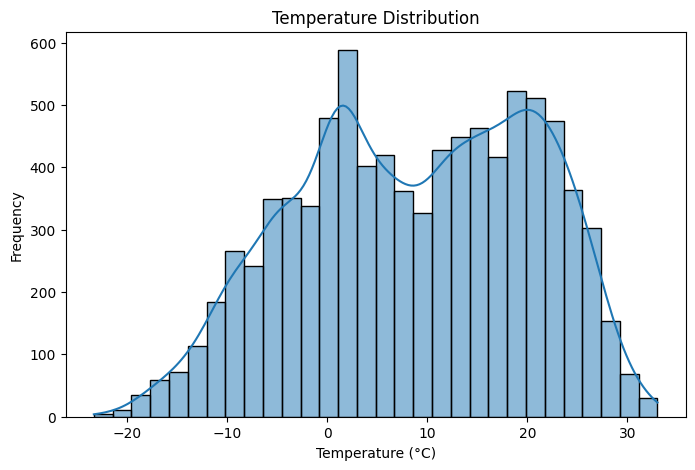

In [55]:
# Visualize the distribution of temperature values
plt.figure(figsize=(8, 5))

sns.histplot(df["Temp_C"], bins=30, kde=True)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

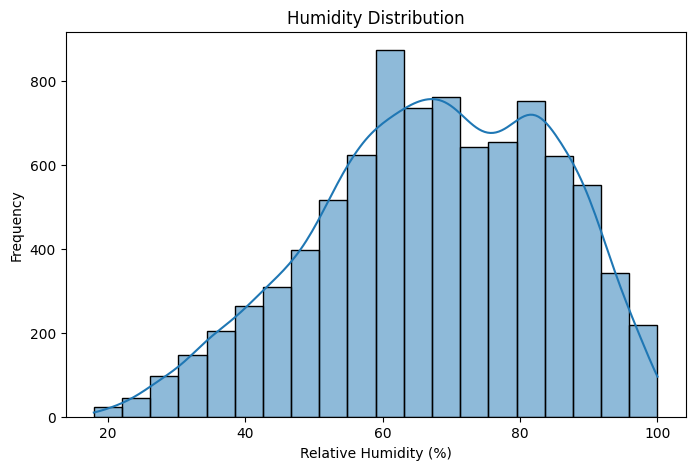

In [56]:
# Visualize the distribution of Humidity values
plt.figure(figsize=(8, 5))

sns.histplot(df["Rel Hum_%"], bins=20, kde=True)

plt.title("Humidity Distribution")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Frequency")

plt.show()

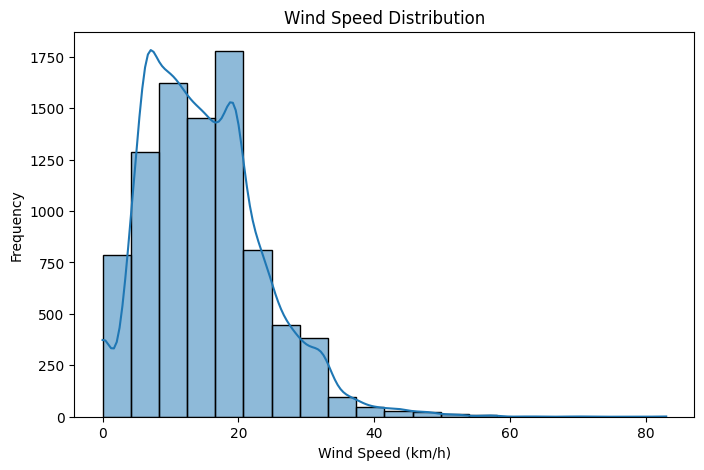

In [58]:
# Visualize the distribution of Wind Speed values
plt.figure(figsize=(8, 5))

sns.histplot(df["Wind Speed_km/h"], bins=20, kde=True)

plt.title("Wind Speed Distribution")
plt.xlabel("Wind Speed (km/h)")
plt.ylabel("Frequency")

plt.show()

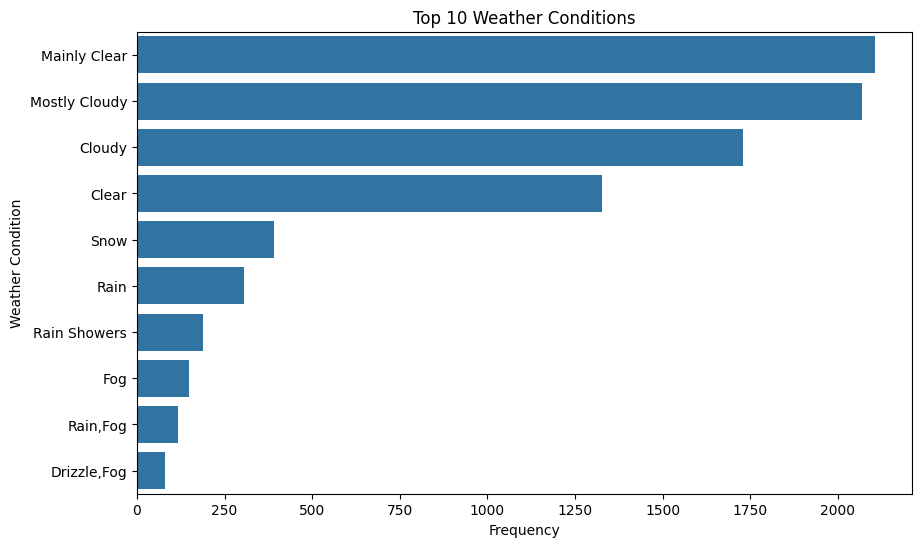

In [ ]:
# Get the 10 most frequent weather conditions
weather_counts = df["Weather"].value_counts().head(10)

# Create a bar chart
plt.figure(figsize=(10, 6))

sns.barplot(
    x=weather_counts.values,
    y=weather_counts.index
)

plt.title("Top 10 Weather Conditions")
plt.xlabel("Frequency")
plt.ylabel("Weather Condition")

plt.show()

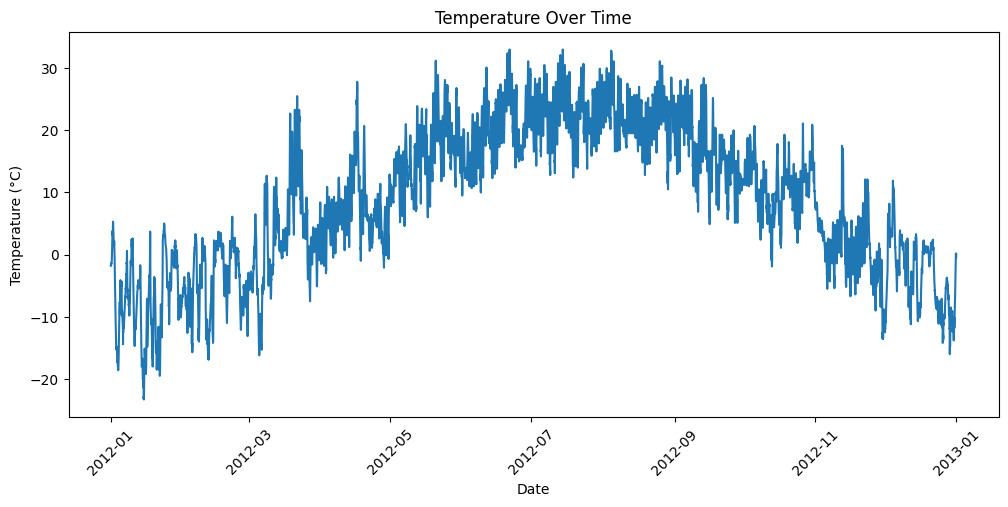

In [ ]:
# Plot temperature changes over time
plt.figure(figsize=(12, 5))

plt.plot(df["Date/Time"], df["Temp_C"])

plt.title("Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.xticks(rotation=45)
plt.show()

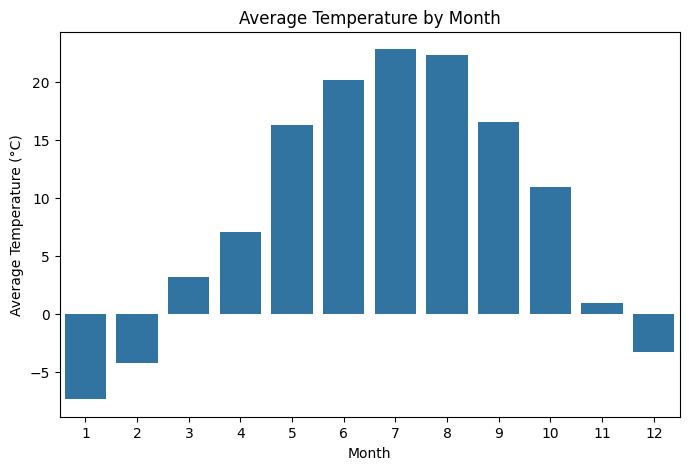

In [ ]:
# Calculate the average temperature for each month
monthly_temp = df.groupby("Month")["Temp_C"].mean()

# Create a bar chart
plt.figure(figsize=(8, 5))

sns.barplot(
    x=monthly_temp.index,
    y=monthly_temp.values
)

plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")

plt.show()

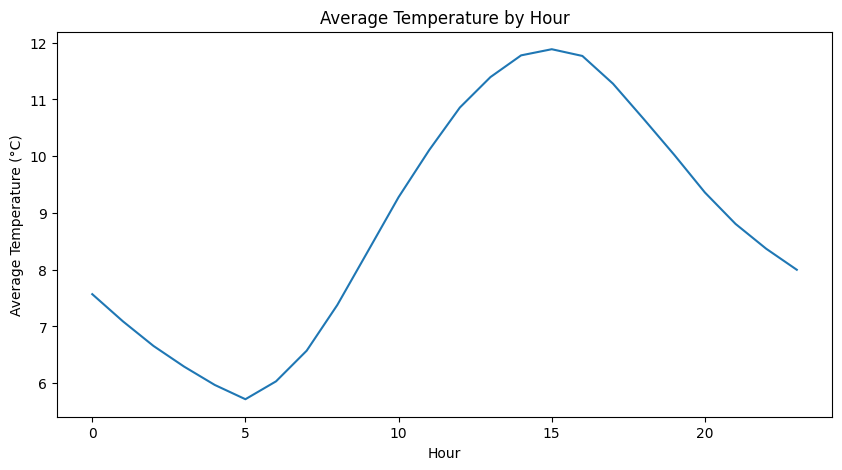

In [ ]:
# Calculate the average temperature for each hour
hourly_temp = df.groupby("Hour")["Temp_C"].mean()

# Create a line plot
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=hourly_temp.index,
    y=hourly_temp.values
)

plt.title("Average Temperature by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Temperature (°C)")

plt.show()

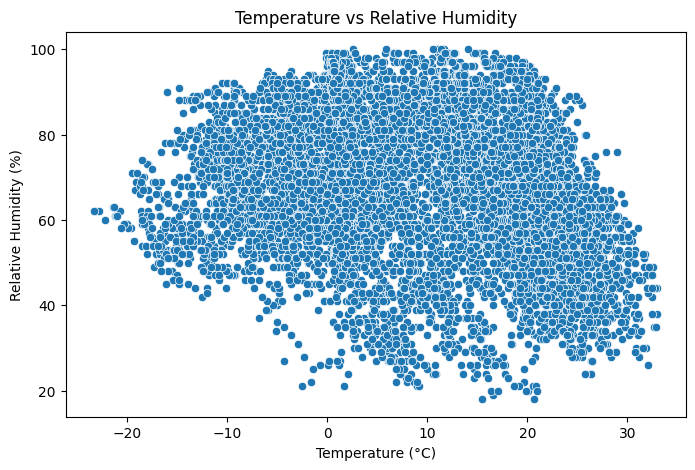

In [ ]:
# Create a scatter plot to study the relationship between temperature and humidity
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Temp_C",
    y="Rel Hum_%"
)

plt.title("Temperature vs Relative Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")

plt.show()

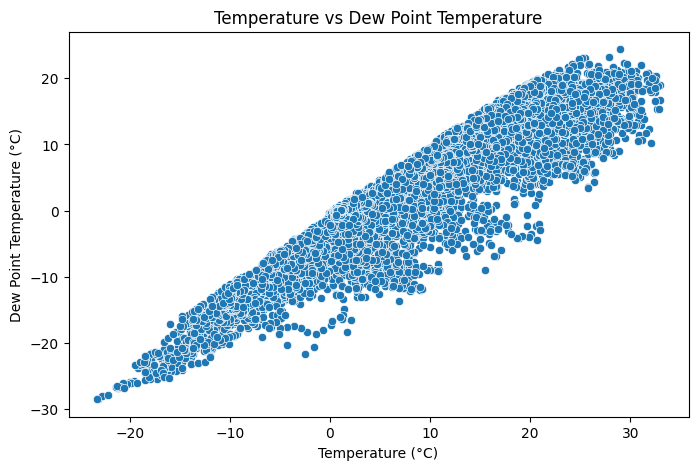

In [ ]:
# Create a scatter plot to study the relationship between temperature and dew point
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Temp_C",
    y="Dew Point Temp_C"
)

plt.title("Temperature vs Dew Point Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Dew Point Temperature (°C)")

plt.show()

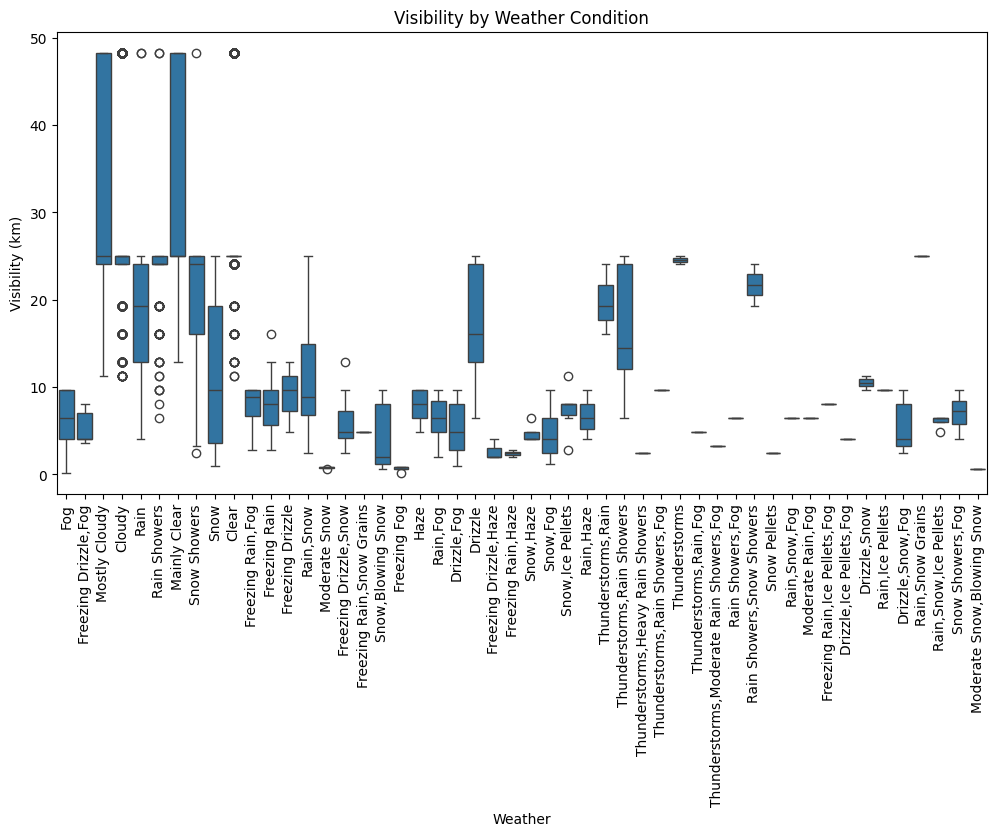

In [ ]:
# Create a box plot to compare visibility across weather conditions
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Weather",
    y="Visibility_km"
)

plt.xticks(rotation=90)

plt.title("Visibility by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Visibility (km)")

plt.show()

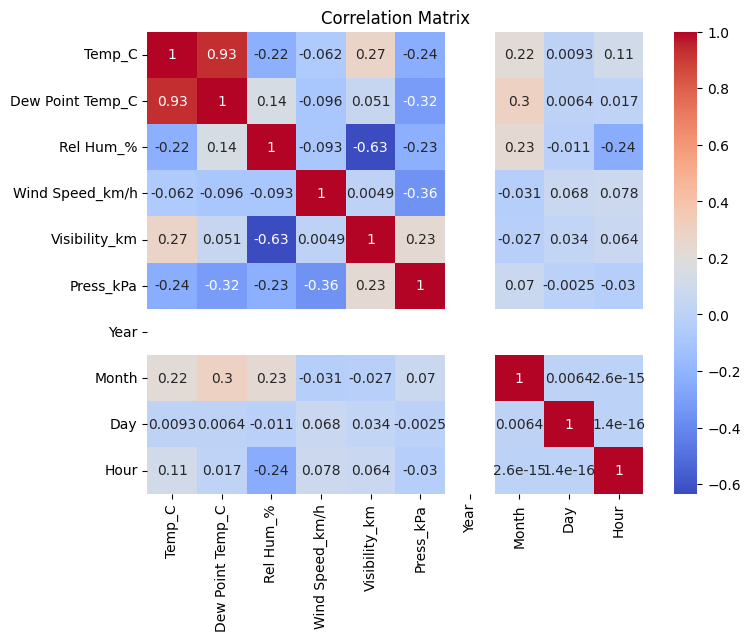

In [ ]:
# Select numerical columns and calculate their correlations
correlation = df.select_dtypes(include="number").corr()

# Create a heatmap to visualize correlations
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

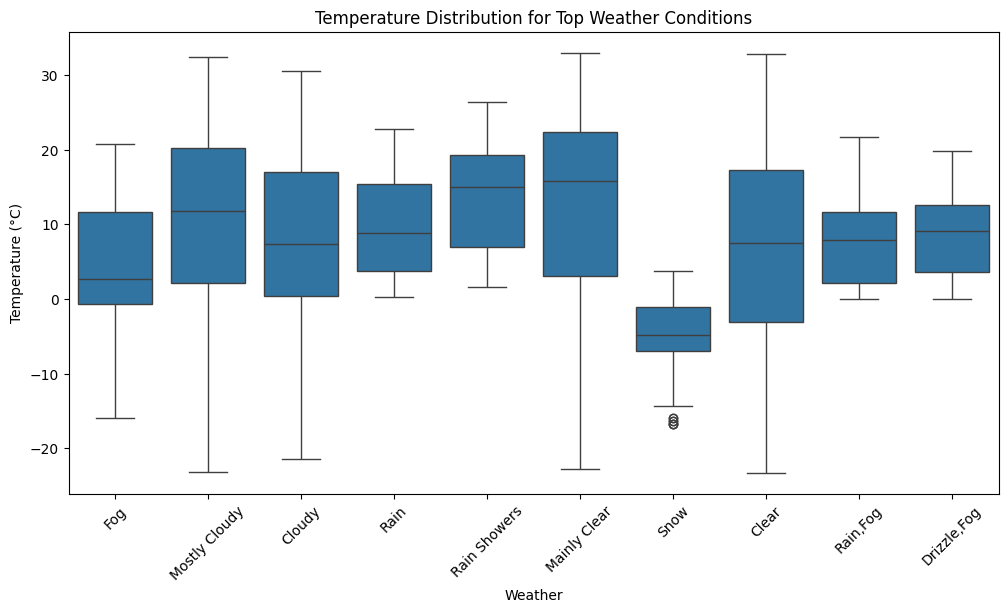

In [ ]:
# Get the 10 most common weather conditions
top_weather = df["Weather"].value_counts().head(10).index

# Keep only rows belonging to the top 10 weather conditions
weather_temp = df[df["Weather"].isin(top_weather)]

# Create a box plot to compare temperature across weather conditions
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=weather_temp,
    x="Weather",
    y="Temp_C"
)

plt.xticks(rotation=45)

plt.title("Temperature Distribution for Top Weather Conditions")
plt.xlabel("Weather")
plt.ylabel("Temperature (°C)")

plt.show()